<a href="https://colab.research.google.com/github/jamshid719/pytorch_dive_deep/blob/main/01_pytorch_workflow_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cu128


In [56]:
!nvidia-smi

Tue Sep  1 12:54:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             29W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

###Workflow: 1. data(pre and load) => 2. build model(or use pretrained model) => 3. training => 4. making predictions and evaluvating a model => 5. saving model => 6. putting it all together

## 1. Data (preparing and loading)

In [57]:
import sklearn
from sklearn.datasets import make_circles

In [58]:
# make 1000 samples
n_samples = 1000

#create circles
X, y = make_circles(n_samples, noise = 0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [59]:
import pandas as pd
circles = pd.DataFrame({ "X1": X[:, 0], "X2": X[:, 1], "label": y })
circles.head(7)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1


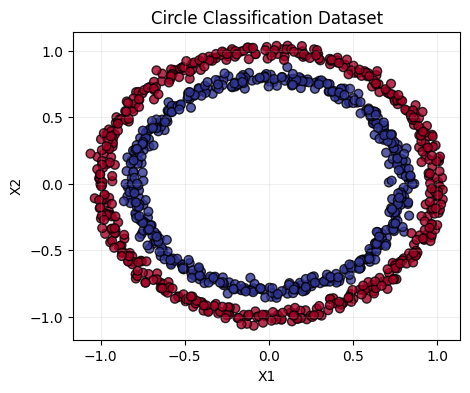

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
    s=40,
    alpha=0.8,
    edgecolors="black"
)

plt.title("Circle Classification Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.2)

plt.show()

In [61]:
#View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")



Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [62]:
import torch
torch.__version__

'2.11.0+cu128'

In [63]:
# Turn data into tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

X[:5], y[:5]



(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [64]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [65]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% is for test data
    random_state=42
)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and test loop

In [66]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

device


'cuda'

In [67]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(
            in_features=2,
            out_features=5
        )

        self.layer_2 = nn.Linear(
            in_features=5,
            out_features=1
        )

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x))  # x -> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)

model_0
# model_0.state_dict()

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [68]:
# replicate this model by nn.Sequential() => kod qisqaroq buladi
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        # 2. Create 2 nn.Sequential()
        self.model = nn.Sequential(
               nn.Linear(2, 5),
               nn.Linear(5, 1)
        )


    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.model(x) # x -> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)

model_0
# model_0.state_dict()

CircleModelV0(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [69]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))

print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 5 predictions:\n{untrained_preds[:5]}")
print(f"\nFirst 5 labels:\n{y_test[:5]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 5 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

First 5 labels:
tensor([1., 0., 1., 0., 1.])


2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might want MAE or MSE
(mean absolute error or mean squared error).

For classification you might want binary cross entropy
or categorical cross entropy (cross entropy).

In [70]:
#Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss() = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr =0.1)

In [71]:
# Calculate accuracy => modelning nechta prediction’i to‘g‘ri chiqqanini foizda ko‘rsatadi.
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

3. Train model

To train our model, we're going to need to build a training loop with the following steps:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these logits into prediction probabilities by passing them to some kind of activation function
(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them
or taking the argmax().

In [72]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()

with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [73]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [74]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)

y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:

• y_pred_probs >= 0.5, y=1 (class 1)
• y_pred_probs < 0.5, y=0 (class 0)

In [75]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(
    torch.sigmoid(
        model_0(X_test.to(device))[:5]
    )
)

# Check for equality
print(
    torch.eq(
        y_preds.squeeze(),
        y_pred_labels.squeeze()
    )
)

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [76]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

##3.2 Building a training and testing loop

In [77]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze() # turn logits ->
    y_pred = torch.round(torch.sigmoid(y_logits)) #  -> pred probs -> pred labels(by torch.round)

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(
    y_true=y_train,
    y_pred=y_pred
    )

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()

    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(
        test_logits,
        y_test
        )

        test_acc = accuracy_fn(
        y_true=y_test,
        y_pred=test_pred
        )

    # Print out what's happenin'
    if epoch % 10 == 0:
       print(
        f"Epoch: {epoch} | "
        f"Loss: {loss:.5f}, Acc: {acc:.2f}% | "
        f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%"
    )




Epoch: 0 | Loss: 0.69796, Acc: 51.88% | Test loss: 0.69440, Test acc: 58.00%
Epoch: 10 | Loss: 0.69590, Acc: 51.25% | Test loss: 0.69305, Test acc: 53.00%
Epoch: 20 | Loss: 0.69490, Acc: 51.62% | Test loss: 0.69254, Test acc: 49.50%
Epoch: 30 | Loss: 0.69435, Acc: 51.12% | Test loss: 0.69236, Test acc: 49.50%
Epoch: 40 | Loss: 0.69401, Acc: 50.88% | Test loss: 0.69232, Test acc: 51.00%
Epoch: 50 | Loss: 0.69378, Acc: 50.25% | Test loss: 0.69234, Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Acc: 50.00% | Test loss: 0.69239, Test acc: 51.50%
Epoch: 70 | Loss: 0.69351, Acc: 50.25% | Test loss: 0.69246, Test acc: 51.00%
Epoch: 80 | Loss: 0.69342, Acc: 49.88% | Test loss: 0.69254, Test acc: 50.00%
Epoch: 90 | Loss: 0.69336, Acc: 49.88% | Test loss: 0.69262, Test acc: 53.00%


##4. Make predictions and evaluate the model

In [78]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    )
    with open("helper_functions.py", "wb") as f:
       f.write(request.content)
from helper_functions import plot_predictions, plot_decision_boundary

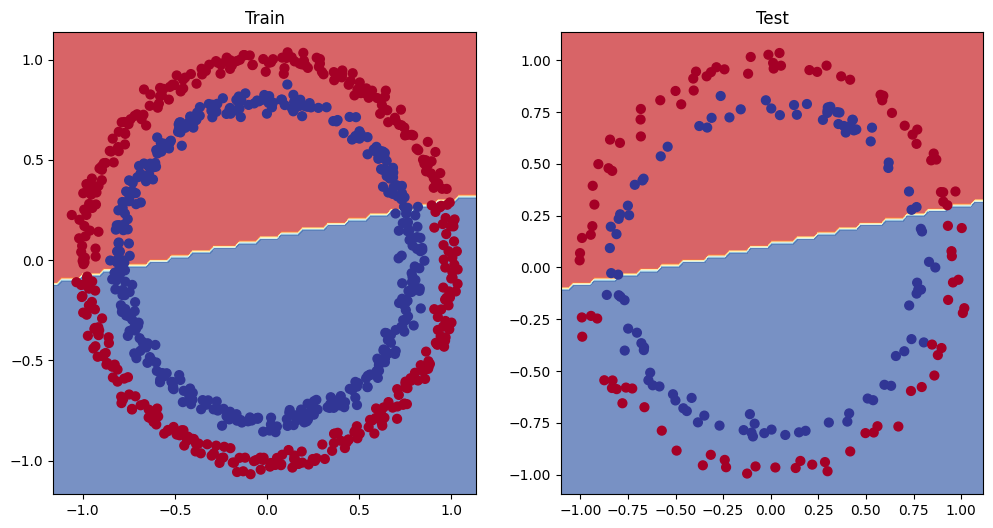

In [79]:
# Plot decision boundary of the model_0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

##5. Improving a model (from a model perspective)
Common ways to improve a deep model:

*   Adding more layers

*   Increase the number of hidden units
*   Change/add activation functions
*   Change the optimization function

*   Change the learning rate
*   Fitting for longer

These options are all from a model's perspective because they deal directly with the model, rather than the data.

And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred to as hyperparameters.

FOR EXAMPLE:

learning rate = hyperparameter

epoch = hyperparameter

hidden neurons = hyperparameter

weight = parameter

bias = parameter


In [80]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [81]:
#Setup the loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss() = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_1.parameters(), lr =0.1)

In [82]:
# Write a training and evaluation loop for model_1

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(X_train).squeeze() # turn logits ->
    y_pred = torch.round(torch.sigmoid(y_logits)) #  -> pred probs -> pred labels(by torch.round)

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(
    y_true=y_train,
    y_pred=y_pred
    )

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_1.eval()

    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(
        test_logits,
        y_test
        )

        test_acc = accuracy_fn(
        y_true=y_test,
        y_pred=test_pred
        )

    # Print out what's happenin'
    if epoch % 100 == 0:
       print(
        f"Epoch: {epoch} | "
        f"Loss: {loss:.5f}, Acc: {acc:.2f}% | "
        f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%"
    )

Epoch: 0 | Loss: 0.69396, Acc: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Acc: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Acc: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Acc: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Acc: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%


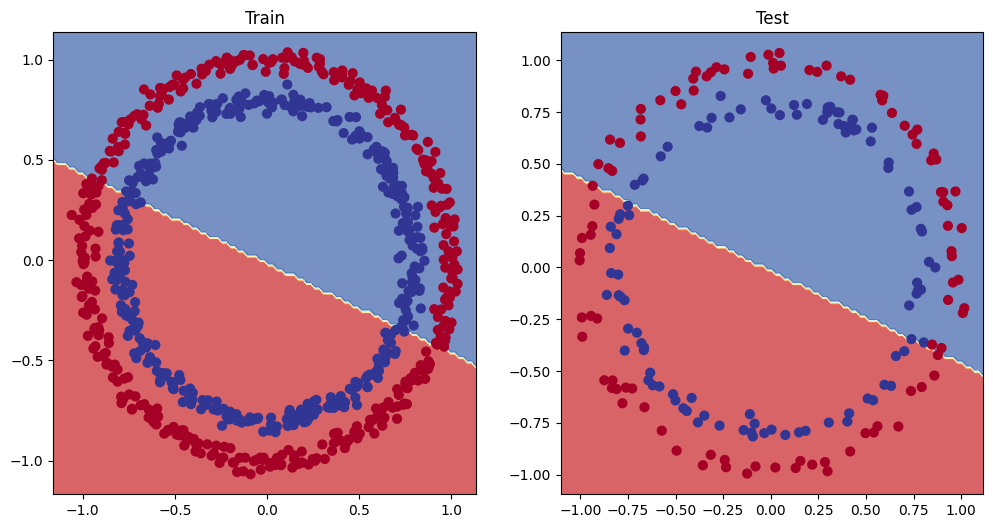

In [83]:
# Plot decision boundary of the model_1
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

##5.2 Adjusting model_1 to fit a straight line

In [84]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias  # Linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [85]:
# Create train and test splits
train_split = int(0.8 * len(X_regression))

X_train_regression, y_train_regression = (
    X_regression[:train_split],
    y_regression[:train_split]
)

X_test_regression, y_test_regression = (
    X_regression[train_split:],
    y_regression[train_split:]
)

# Check the lengths of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

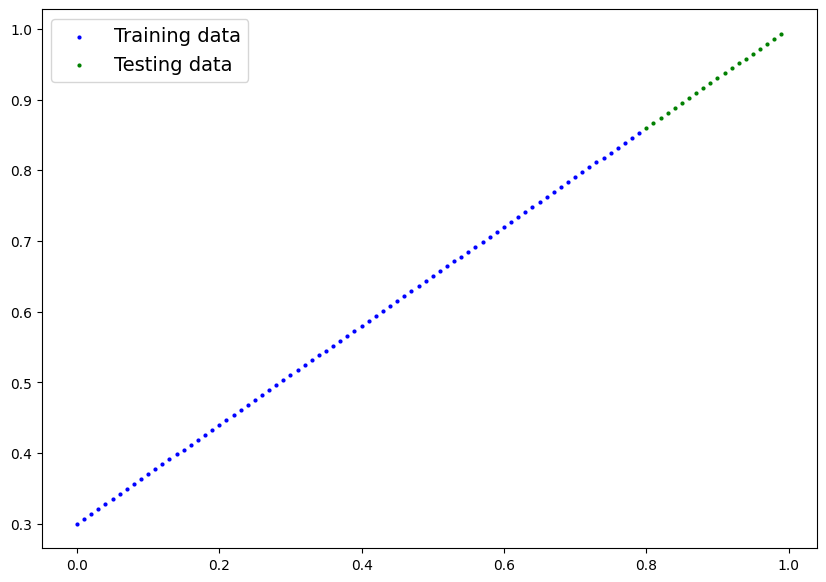

In [86]:
plot_predictions(
    train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
)

In [87]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [88]:
# Loss and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.01
)

In [89]:
# Write a training and evaluation loop for model_1

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
    y_pred = model_2(X_train_regression)

    loss = loss_fn(
        y_pred,
        y_train_regression
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_2.eval()

    with torch.inference_mode():
        test_pred = model_2(X_test_regression)

        test_loss = loss_fn(
            test_pred,
            y_test_regression
        )

    # Print out what's happenin'
    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.5f} | "
            f"Test loss: {test_loss:.5f}"
        )

Epoch: 0 | Loss: 0.75986 | Test loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test loss: 0.00360


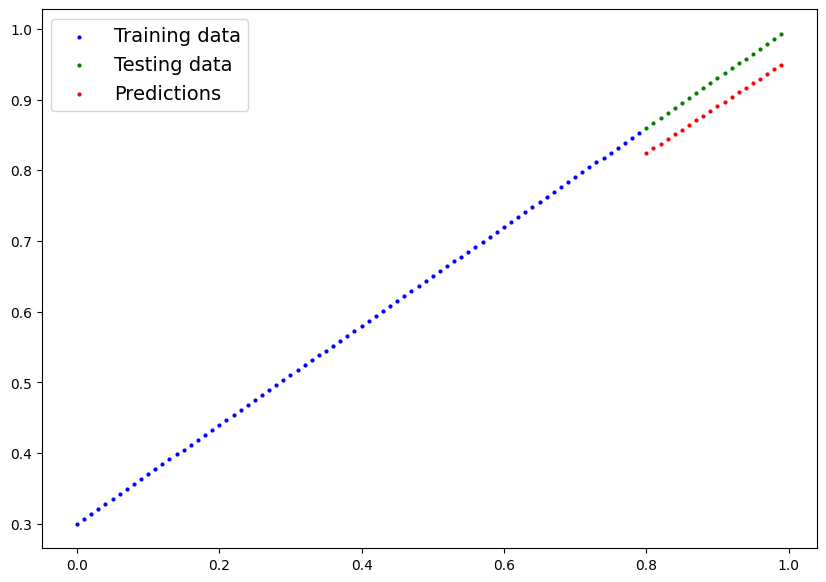

In [90]:
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(
    train_data=X_train_regression.cpu(),
    train_labels=y_train_regression.cpu(),
    test_data=X_test_regression.cpu(),
    test_labels=y_test_regression.cpu(),
    predictions=y_preds.cpu()
)

##6. Adjust missing data to non-linearity



In [91]:
#Build a model with non-linear activation functions
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=15)
        self.layer_2 = nn.Linear(in_features=15, out_features=25)
        self.layer_3 = nn.Linear(in_features=25, out_features=1)
        self.relu = nn.ReLU() # relu is a non-linear activation func.

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=25, bias=True)
  (layer_3): Linear(in_features=25, out_features=1, bias=True)
  (relu): ReLU()
)

In [92]:
#Setup the loss function and optimizer

loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss() = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_3.parameters(), lr =0.1)

##6.1 Training a model with non-linearity

In [93]:
# Write a training and evaluation loop for model_1

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_3.train()

    # 1. Forward pass
    y_logits = model_3(X_train).squeeze() # turn logits ->
    y_pred = torch.round(torch.sigmoid(y_logits)) #  -> pred probs -> pred labels(by torch.round)

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(
    y_true=y_train,
    y_pred=y_pred
    )

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_3.eval()

    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(
        test_logits,
        y_test
        )

        test_acc = accuracy_fn(
        y_true=y_test,
        y_pred=test_pred
        )

    # Print out what's happenin'
    if epoch % 100 == 0:
       print(
        f"Epoch: {epoch} | "
        f"Loss: {loss:.5f}, Acc: {acc:.2f}% | "
        f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%"
    )

Epoch: 0 | Loss: 0.69809, Acc: 50.00% | Test loss: 0.69874, Test acc: 50.00%
Epoch: 100 | Loss: 0.68878, Acc: 57.12% | Test loss: 0.69100, Test acc: 53.50%
Epoch: 200 | Loss: 0.68440, Acc: 59.88% | Test loss: 0.68786, Test acc: 57.50%
Epoch: 300 | Loss: 0.67884, Acc: 62.12% | Test loss: 0.68410, Test acc: 60.00%
Epoch: 400 | Loss: 0.67065, Acc: 66.12% | Test loss: 0.67825, Test acc: 62.50%
Epoch: 500 | Loss: 0.65703, Acc: 69.50% | Test loss: 0.66756, Test acc: 65.00%
Epoch: 600 | Loss: 0.63362, Acc: 75.75% | Test loss: 0.64798, Test acc: 72.00%
Epoch: 700 | Loss: 0.58976, Acc: 91.50% | Test loss: 0.60871, Test acc: 90.50%
Epoch: 800 | Loss: 0.50996, Acc: 98.50% | Test loss: 0.53593, Test acc: 96.50%
Epoch: 900 | Loss: 0.38333, Acc: 99.75% | Test loss: 0.41874, Test acc: 99.50%


##6.2 Evaluvating a model trained with non-linear activation functions

In [94]:
# Makes predictions
model_3.eval()

with torch.inference_mode():
    y_preds = torch.round(
        torch.sigmoid(
            model_3(X_test)
        )
    ).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

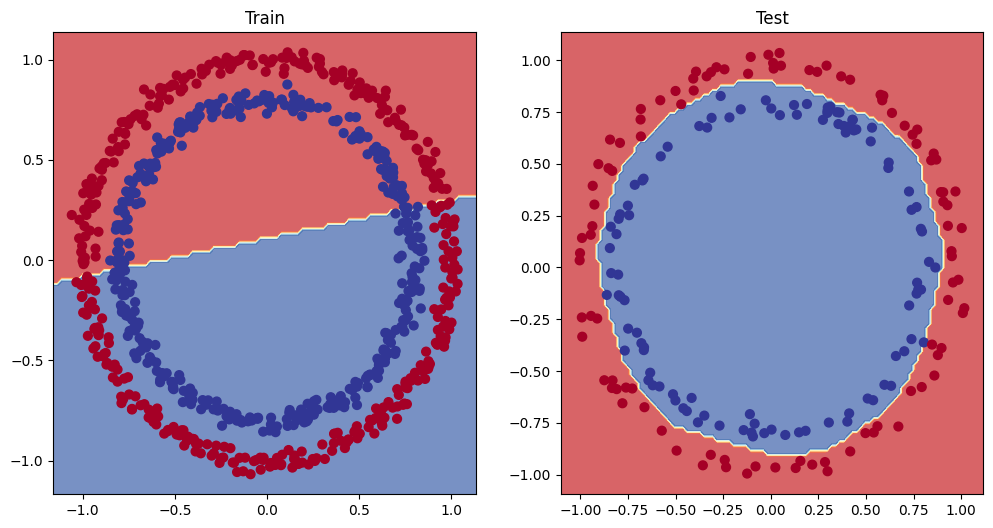

In [95]:
# Plot decision boundary of the model_3
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

##7. Putting all togather with a multi-class classification problem
###7.1 Creating a toy-multi-class dataset

Text(0, 0.5, 'Feature 2')

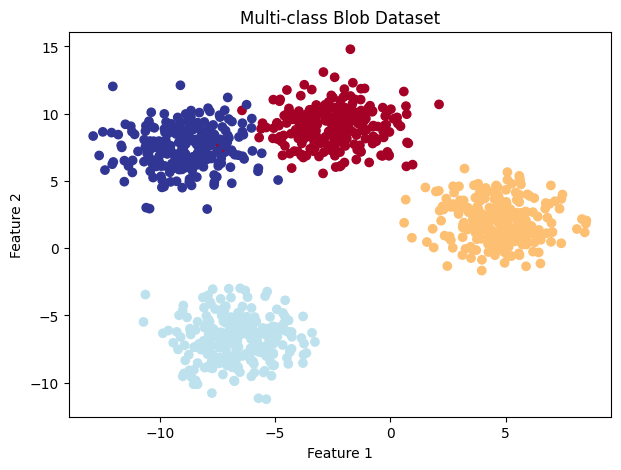

In [96]:
# Import dependencies
import torch
from torch import nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    cluster_std=1.5,  # give the clusters a little shake up
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data (visualize, visualize, visualize)
plt.figure(figsize=(7, 5))

plt.scatter(
    X_blob[:, 0],
    X_blob[:, 1],
    c=y_blob,
    cmap=plt.cm.RdYlBu
)
plt.title("Multi-class Blob Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")


##7.2 Building a multi-class classification model in PyTorch

In [97]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [113]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(
                in_features=input_features,
                out_features=hidden_units
            ),
            # nn.ReLU(),
            nn.Linear(
                in_features=hidden_units,
                out_features=hidden_units
            ),
            # nn.ReLU(),
            nn.Linear(
                in_features=hidden_units,
                out_features=output_features
            )
        )

    def forward(self, x):
      return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(
    input_features=2,
    output_features=4,
    hidden_units=8
).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [100]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

In [117]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0], device='cuda:0'))

In [118]:
# Create a loss function for multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer for multi-class classification
optimizer = torch.optim.SGD(
    params=model_4.parameters(),
    lr=0.1
)

##7.3 Getting prediction probabilities for a multi-class PyTorch model

Logits(raw output of the model) -> Pred probs(use torch.softmax) -> Pred labels(take the argmax of the Pred probs)

In [119]:
# Let's get some raw outputs of our model (logits)
model_4.eval()

with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]], device='cuda:0')

In [120]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0')


In [121]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)

y_preds

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3], device='cuda:0')

In [122]:
# Write a training and evaluation loop for model_4

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # turn logits ->
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) #  -> pred probs -> pred labels
    # y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1) # bu ham tugri


    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_blob_train)

    acc = accuracy_fn(
    y_true=y_blob_train,
    y_pred=y_pred
    )

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_4.eval()

    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        # 2. Calculate test loss/acc
        test_loss = loss_fn(
        test_logits,
        y_blob_test
        )

        test_acc = accuracy_fn(
        y_true=y_blob_test,
        y_pred=test_preds
        )

    # Print out what's happenin'
    if epoch % 10 == 0:
       print(
        f"Epoch: {epoch} | "
        f"Loss: {loss:.4f}, Acc: {acc:.2f}% | "
        f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%"
    )

Epoch: 0 | Loss: 1.0432, Acc: 65.50% | Test loss: 0.5786, Test acc: 95.50%
Epoch: 10 | Loss: 0.1440, Acc: 99.12% | Test loss: 0.1304, Test acc: 99.00%
Epoch: 20 | Loss: 0.0806, Acc: 99.12% | Test loss: 0.0722, Test acc: 99.50%
Epoch: 30 | Loss: 0.0592, Acc: 99.12% | Test loss: 0.0513, Test acc: 99.50%
Epoch: 40 | Loss: 0.0489, Acc: 99.00% | Test loss: 0.0410, Test acc: 99.50%
Epoch: 50 | Loss: 0.0429, Acc: 99.00% | Test loss: 0.0349, Test acc: 99.50%
Epoch: 60 | Loss: 0.0391, Acc: 99.00% | Test loss: 0.0308, Test acc: 99.50%
Epoch: 70 | Loss: 0.0364, Acc: 99.00% | Test loss: 0.0280, Test acc: 99.50%
Epoch: 80 | Loss: 0.0345, Acc: 99.00% | Test loss: 0.0259, Test acc: 99.50%
Epoch: 90 | Loss: 0.0330, Acc: 99.12% | Test loss: 0.0242, Test acc: 99.50%


##7.4 Making and evaluating predictions with a PyTorch multi-class model

In [123]:
# Make predictions
model_4.eval()

with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:7]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0726,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179]], device='cuda:0')

In [124]:
# Go from logits -> prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

y_pred_probs[:7]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3698e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2267e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5436e-08, 4.7620e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4288e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04]], device='cuda:0')

In [125]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:7]

tensor([1, 3, 2, 1, 0, 3, 2], device='cuda:0')

In [126]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

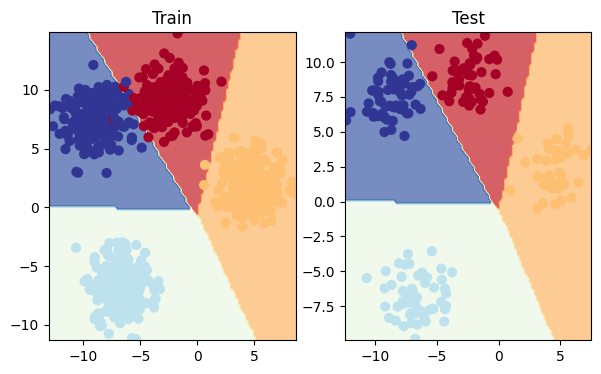

In [131]:
# 4. Plot data (visualize, visualize, visualize)
plt.figure(figsize=(7, 4))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics... (to evaluate our classification model)
Accuracy  → umumiy nechta prediction to‘g‘ri

Precision → model "positive" deganlarning nechasi haqiqatan positive

Recall    → haqiqiy positive'larning nechasini model topdi

F1-score  → precision va recall balansini ko‘rsatadi

Confusion matrix → qaysi classni qaysi class bilan adashtirganini ko‘rsatadi

Classification report → precision, recall, F1-score va support'ni bir joyda beradi

BEACAUSE: Lekin accuracy har doim yetarli emas. Masalan classlar noteng bo‘lsa, precision, recall, F1-score muhimroq bo‘lishi mumkin.

See this article for when to use precision/recall -
https://towardsdatascience.com/beyond-accuracy-precision-and-recall-3da06bea9f6c

If you want access to a lot of PyTorch metrics, see TorchMetrics -
https://torchmetrics.readthedocs.io/en/latest/

In [132]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.5 MB/s eta 0:00:00


In [138]:
from torchmetrics import Accuracy

torchmetric_accuracy = Accuracy(
    task="multiclass",
    num_classes=4
).to(device)

torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')